In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In the following the string graph as exported from cytoscape is read into a undirected graph

In [2]:
# Load the network as an undirected graph
G = nx.read_graphml("../data/graphml_string_cleaned.graphml").to_undirected()
# relable the nodes with the 'stringdb::canonical name' attribute
G = nx.relabel_nodes(G, nx.get_node_attributes(G, 'stringdb::canonical name'))


In [20]:
# read in the csv "convertDeeProM_alldrug.csv" check if the protein is in the network by using the value in the "converted_alias" column
# if the protein is in the network, add the protein to a dictionary with the key being the uniprot ID found in the network and the value being the protein symbol found in the csv under "initial_alias"

# read in the csv "convertDeeProM_alldrug.csv"
import csv
uniprot2symbol = {}
with open('../data/convertDeeProM_alldrug.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        # check if the protein is in the network by using the value in the "converted alias" column
        if row['converted_alias'] in G.nodes():
            # if the protein is in the network, add the protein to a dictionary with the key being the uniprot ID found in the network and the value being the protein symbol found in the csv under initial alias
            uniprot2symbol[row['converted_alias']] = row['initial_alias']

#generate the reverse dictionary
symbol2uniprot = {v: k for k, v in uniprot2symbol.items()}
print(len(uniprot2symbol))
    




2357


In [21]:
print(symbol2uniprot)

{'AACS': 'Q86V21', 'AAGAB': 'Q6PD74', 'AARS2': 'Q5JTZ9', 'AASDHPPT': 'Q9NRN7', 'AATF': 'Q9NY61', 'ABCB1': 'P08183', 'ABCB6': 'Q9NP58', 'ABCD1': 'P33897', 'ABCE1': 'P61221', 'ABCF1': 'Q8NE71', 'ABCF2': 'Q9UG63', 'ABHD10': 'Q9NUJ1', 'ABHD14B': 'Q96IU4', 'ABHD16A': 'O95870', 'ABHD6': 'Q9BV23', 'ACAA1': 'P09110', 'ACAA2': 'P42765', 'ACAD9': 'Q9H845', 'ACADVL': 'P49748', 'ACAT2': 'Q9BWD1', 'ACIN1': 'Q9UKV3', 'ACLY': 'P53396', 'ACO2': 'Q99798', 'ACOT13': 'Q9NPJ3', 'ACOT9': 'Q9Y305', 'ACP1': 'D3YTI2', 'ACSF2': 'Q96CM8', 'ACSL1': 'P33121', 'ACSL3': 'O95573', 'ACSL4': 'O60488', 'ACSS1': 'Q9NUB1', 'ACSS3': 'Q9H6R3', 'ACTBL2': 'Q562R1', 'ACTL6A': 'O96019', 'ACTN1': 'P12814', 'ACTN4': 'O43707', 'ACTR1A': 'P61163', 'ACTR2': 'P61160', 'ACTR3': 'P61158', 'ACY1': 'Q03154', 'ADA': 'P00813', 'ADAM10': 'O14672', 'ADAM17': 'P78536', 'ADAM9': 'Q13443', 'ADAR': 'P55265', 'ADGRG1': 'Q9Y653', 'ADH5': 'P11766', 'ADNP': 'Q9H2P0', 'ADRM1': 'Q16186', 'ADSL': 'P30566', 'AFAP1': 'Q8N556', 'AFAP1L2': 'Q8N4X5', 'AFG3

In [23]:
#load the excel file s5.xlsx, add add the uniprot ID to the column "UniprotID_inString" using the symvol2uniprot dictionary and the symbol in the column "x_id"
# if the symbol is not in the dictionary, add the symbol to the column "UniprotID_inString" as "not found"
import pandas as pd
df = pd.read_excel('../data/s5.xlsx', header=0, sheet_name=3)
df['UniprotID_inString'] = df['x_id'].map(symbol2uniprot).fillna('not found')
print(df.head())
#write the dataframe to a new excel file "s5_with_uniprot.xlsx"
df.to_excel('../data/s5_with_uniprot.xlsx', index=False)


     ID   drug_name   GDSC                  y_id   x_id    n      beta  \
0  2293      AMG900  GDSC2     2293;AMG900;GDSC2    SPN   61  1.398757   
1   428  Pemetrexed  GDSC1  428;Pemetrexed;GDSC1  PYGO2   65  1.093979   
2  1427     AZD5582  GDSC1    1427;AZD5582;GDSC1  UBE3C   81  1.021381   
3  1218         JQ1  GDSC1        1218;JQ1;GDSC1  EEF2K   85  0.984401   
4  1997    WEHI-539  GDSC2   1997;WEHI-539;GDSC2  CAMK4  107  0.981336   

       pval       fdr   nc_beta   nc_pval    nc_fdr        r2  \
0  0.000015  0.079201  0.671541  0.001369  0.068626  0.574973   
1  0.000124  0.080144  0.807800  0.006577  0.136532  0.692758   
2  0.001898  0.041159  0.715484  0.024800  0.104059  0.579682   
3  0.000007  0.036609  0.701627  0.000377  0.342404  0.490030   
4  0.001455  0.075886  0.380969  0.218905  0.519665  0.462995   

                target ppi      skew  cancer_gene UniprotID_inString  
0    AURKA;AURKB;AURKC   - -1.069289        False             P16150  
1                 TYMS

In [24]:
#print the first node and its attributes
print(list(G.nodes())[0])
print(G.nodes[list(G.nodes())[0]])



O43264
{'SUID': 16943, 'shared name': '9606.ENSP00000200135', 'name': '9606.ENSP00000200135', 'selected': False, 'stringdb::canonical name': 'O43264', 'display name': 'ZW10', 'stringdb::database identifier': '9606.ENSP00000200135', 'stringdb::description': 'Centromere/kinetochore protein zw10 homolog; Essential component of the mitotic checkpoint, which prevents cells from prematurely exiting mitosis. Required for the assembly of the dynein-dynactin and MAD1-MAD2 complexes onto kinetochores. Its function related to the spindle assembly machinery is proposed to depend on its association in the mitotic RZZ complex. Involved in regulation of membrane traffic between the Golgi and the endoplasmic reticulum (ER); the function is proposed to depend on its association in the interphase NRZ complex which is believed to play a role in SNARE assembly at the ER; Belongs to the ZW10 family.', '@id': 'stringdb:9606.ENSP00000200135', 'stringdb::namespace': 'stringdb', 'stringdb::node type': 'protein

In [28]:
def generate_ego_network(id, radius):
    try:
        ego_graph = nx.ego_graph(G, id, radius=radius, undirected=True, center=True)
    except:
        print("The id is not in the graph")
        return 
    return ego_graph
    

In [29]:
from functools import partial
def generate_get_intersections(ego_dict):
  #generate a partial function which sets thte ego_dict of get_intersection
  return partial(get_intersections, ego_dict)

def get_intersections(ego_graphs, id1, id2):
  if id1 == id2:
    return -1
  try:
    #find the common nodes between the two ego networks
    common_nodes = set(ego_graphs[id1].nodes()).intersection(set(ego_graphs[id2].nodes()))
    #return the length of the common nodes
  except:
    #print("No ego graph found: {}, {}".format(id1, id2))
    return -1
  return len(common_nodes)


In [30]:
from functools import partial
def generate_get_jaccard_indes(ego_dict):
  #generate a partial function which sets thte ego_dict of get_intersection
  return partial(get_jaccard_index, ego_dict)

##calculate the jaccard index between the two ego networks
def get_jaccard_index(ego_graphs,id1,id2):
  if id1 == id2:
    return -1
  try:
    #find the common nodes between the two ego networks
    common_nodes = set(ego_graphs[id1].nodes()).intersection(set(ego_graphs[id2].nodes()))
    #find the union of the two ego networks
    union_nodes = set(ego_graphs[id1].nodes()).union(set(ego_graphs[id2].nodes()))
    #return the jaccard index
  except:
    #print("No ego graph found: {}, {}".format(id1, id2))
    return -1
  return len(common_nodes)/len(union_nodes)

In [18]:
allIDs = ["P49790", "Q9UMS4", "Q99459", "Q8WWY3", "P61978", "P57740", "P57740", "P14314", "P14314", "Q14498", "P49790", "P30050", "P48729", "Q7KZF4", "P12270", "O43447", "Q9GZT3", "Q9GZT3", "P11142", "P19387", "Q8N983", "Q9UBS4", "Q9NXW2", "P61421", "P51452", "Q9NPA0", "P62910", "P62910", "Q92841", "P30050", "P47914", "Q99805", "P62829", "Q6ZRV2", "P46782", "Q8NC56", "Q96EL3", "Q96DV4", "O75477", "Q8IYS2", "P20674", "P83731", "O15226", "P37108", "P37108", "Q5SW79", "O75940", "O95881", "Q96HY7", "P53597", "P42126", "Q06124", "Q13751", "P52789", "Q9H307", "Q13618", "Q13618", "P63279", "Q9ULU4", "Q8TCS8", "Q13263", "Q9UNF1", "Q9UBB4", "Q9UBT2", "Q9BTE3", "Q9BTE3", "O43752", "P52565", "Q9UBE0", "Q92922", "Q14008", "Q96PZ0", "Q9GZR2", "P62263", "P05387", "P78527", "P78527", "Q13586", "Q15369", "P31153", "P05141", "Q15067", "P63220", "Q9UNL2", "O95168", "Q9Y3E5", "Q9NRN7", "Q9UBT2", "P23193", "Q16850", "Q01518", "P07910", "P07910", "Q15102", "Q13492", "Q15370", "Q14566", "P37837", "P00568", "O95373", "P46013", "P30086", "P35580", "P35580", "O75347", "Q99829", "Q14157", "O43765"]

In [25]:
allIDs = list(uniprot2symbol.keys())

len(allIDs)

2357

In [26]:
from multiprocessing import Pool
import pickle

In [21]:
#with Pool(processes=12) as pool:
  #ego_dict_deg1 = dict(zip(allIDs,pool.starmap(generate_ego_network, zip(allIDs, [1]*len(allIDs)))))
  #ego_dict_deg2 = dict(zip(allIDs,pool.starmap(generate_ego_network, zip(allIDs, [2]*len(allIDs)))))
  #ego_dict_deg3 = dict(zip(allIDs,pool.starmap(generate_ego_network, zip(allIDs, [3]*len(allIDs)))))

In [32]:
# split allIDs into chunks and generate the ego networks for each chunk
# then write the ego networks to a pickle file in the data folder
# this is done to avoid memory issues
chunk_size = 500

for i in range(0, len(allIDs), chunk_size):
  with Pool(processes=15) as pool:
    ego_dict_deg2 = dict(zip(allIDs[i:i+chunk_size],pool.starmap(generate_ego_network, zip(allIDs[i:i+chunk_size], [2]*len(allIDs[i:i+chunk_size])))))
    with open("../data/ego_dict_deg2_{}.pickle".format(i), 'wb') as handle:
      pickle.dump(ego_dict_deg2, handle, protocol=pickle.HIGHEST_PROTOCOL)



In [9]:
# read the ego networks from the pickle files
# and merge them into one dictionary
chunk_size = 500
ego_dict_deg2 = {}
for i in range(0, len(allIDs), chunk_size):
  with open("../data/ego_dict_deg2_{}.pickle".format(i), 'rb') as handle:
    ego_dict_deg2.update(pickle.load(handle))


In [10]:
print(len(ego_dict_deg2))

2587


In [11]:
import itertools
# generate all unique pairs of IDs from the list
pairs = list(itertools.combinations(list(ego_dict_deg2.keys()), 2))
print(len(pairs))


3344991


In [12]:
def filter_lt0(vals):
  print("Pre: ",len(vals))
  filtered = [val for val in vals if val > 0]
  print("Post: ",len(filtered))
  return filtered

In [13]:
#intersections1 = filter_lt0([get_intersections(ego_dict_deg1,*pair) for pair in pairs])
intersections2 = filter_lt0([get_intersections(ego_dict_deg2,*pair) for pair in pairs])
#intersections3 = filter_lt0([get_intersections(ego_dict_deg3,*pair) for pair in pairs])
#jaccard1 = filter_lt0([get_jaccard_index(ego_dict_deg1,*pair) for pair in pairs])
jaccard2 = filter_lt0([get_jaccard_index(ego_dict_deg2,*pair) for pair in pairs])
#jaccard3 = filter_lt0([get_jaccard_index(ego_dict_deg3,*pair) for pair in pairs])

Pre:  3344991
Post:  1536197
Pre:  3344991
Post:  1536197


In [16]:
print(len(intersections1))
#filter out the -1 values
intersectionsFilter = [i for i in intersections if i >0]
print(max(intersectionsFilter))

1534093


NameError: name 'intersections' is not defined

In [14]:
import numpy as np

#function to calculate bins for the histogram using the Freedman-Diaconis rule
def freedman_diaconis(data):
  IQR = np.percentile(data, 75) - np.percentile(data, 25)
  bin_width = 2 * IQR * len(data) ** (-1/3)
  return int((max(data) - min(data))/bin_width)

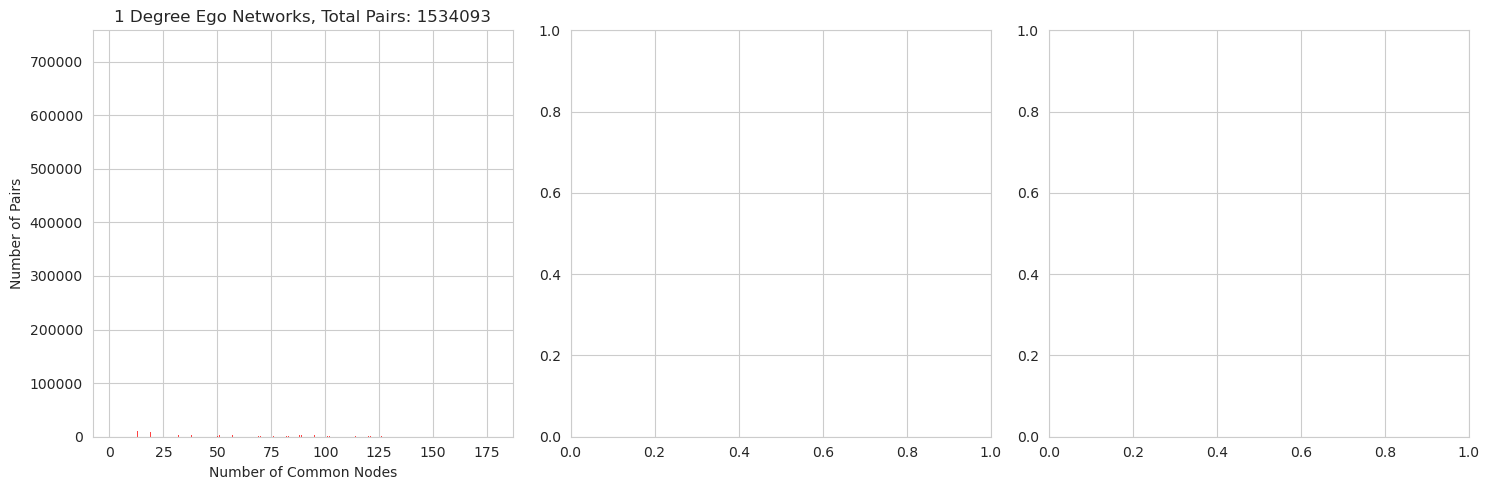

In [18]:
#draw the histograms of the intersection values for 1 degree, 2 degree, and 3 degree ego networks in faceted plots using seaborn the x-axis is the number of common nodes, and should be scaled to the maximum of each specific subplot, and the y-axis is the number of pairs of protein ego-graphs with that number of common nodes
import seaborn as sns
import matplotlib.pyplot as plt

#set the style
sns.set_style("whitegrid")

#plot the histograms
# calculate the number of bins for each plot using the Freedman-Diaconis rule

fig, axes = plt.subplots(1,3, figsize=(15,5), sharex=False)
sns.histplot(intersections1, ax=axes[0], bins=freedman_diaconis(intersections1), color="red")
sns.histplot(intersections2, ax=axes[1], bins=freedman_diaconis(intersections2), color="green")
sns.histplot(intersections3, ax=axes[2], bins=freedman_diaconis(intersections3), color="blue")
axes[0].set_title("1 Degree Ego Networks, Total Pairs: " + str(len(intersections1)))
axes[1].set_title("2 Degree Ego Networks, Total Pairs: " + str(len(intersections2)))
axes[2].set_title("3 Degree Ego Networks, Total Pairs: " + str(len(intersections3)))
axes[0].set_xlabel("Number of Common Nodes")
axes[1].set_xlabel("Number of Common Nodes")
axes[2].set_xlabel("Number of Common Nodes")
axes[0].set_ylabel("Number of Pairs")
axes[1].set_ylabel("Number of Pairs")
axes[2].set_ylabel("Number of Pairs")
plt.tight_layout()




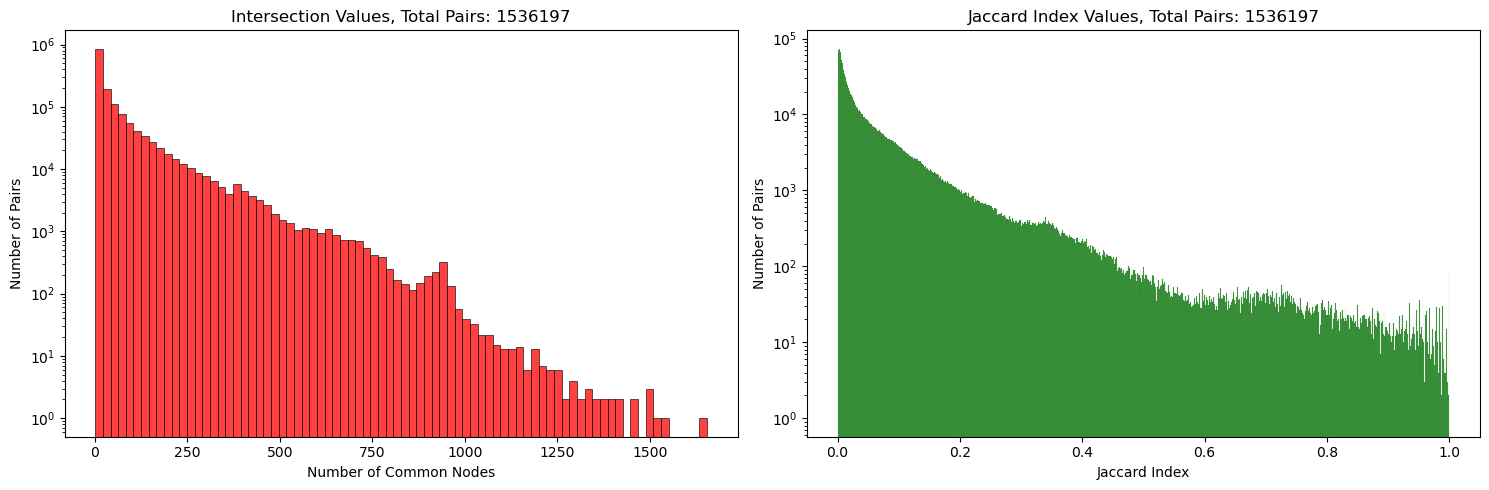

In [15]:
#draw a histogram of intersections1 and jaccard1 use a logscale for the y-axis
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2, figsize=(15,5), sharex=False)
sns.histplot(intersections2, ax=axes[0], bins=80, color="red")
sns.histplot(jaccard2, ax=axes[1], bins=freedman_diaconis(jaccard2), color="green")
axes[0].set_title("Intersection Values, Total Pairs: " + str(len(intersections2)))
axes[1].set_title("Jaccard Index Values, Total Pairs: " + str(len(jaccard2)))
axes[0].set_xlabel("Number of Common Nodes")
axes[1].set_xlabel("Jaccard Index")
axes[0].set_ylabel("Number of Pairs")
axes[1].set_ylabel("Number of Pairs")
axes[0].set_yscale("log")
axes[1].set_yscale("log")
plt.tight_layout()



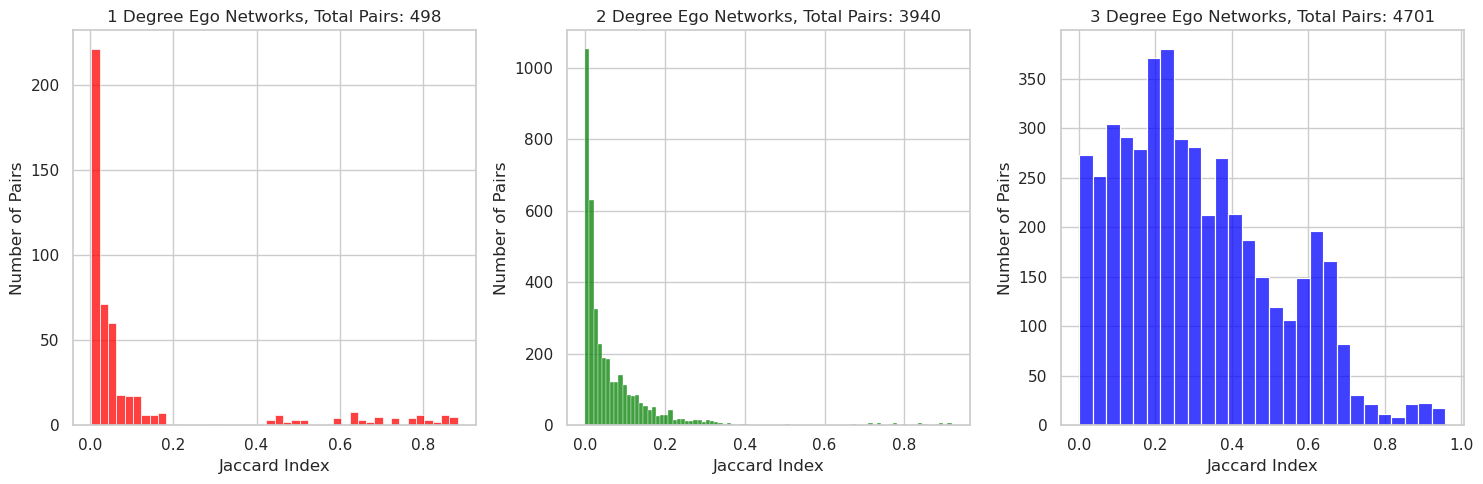

In [ ]:
#draw the histograms of the intersection values for 1 degree, 2 degree, and 3 degree ego networks in faceted plots using seaborn the x-axis is the number of common nodes, and should be scaled to the maximum of each specific subplot, and the y-axis is the number of pairs of protein ego-graphs with that number of common nodes
import seaborn as sns
import matplotlib.pyplot as plt

#set the style
sns.set_style("whitegrid")

#plot the histograms
# calculate the number of bins for each plot using the Freedman-Diaconis rule

fig, axes = plt.subplots(1,3, figsize=(15,5), sharex=False)
sns.histplot(jaccard1, ax=axes[0], bins=freedman_diaconis(jaccard1), color="red")
sns.histplot(jaccard2, ax=axes[1], bins=freedman_diaconis(jaccard2), color="green")
sns.histplot(jaccard3, ax=axes[2], bins=freedman_diaconis(jaccard3), color="blue")
# add the size of the dataset to the plottitle
axes[0].set_title("1 Degree Ego Networks, Total Pairs: " + str(len(jaccard1)))
axes[1].set_title("2 Degree Ego Networks, Total Pairs: " + str(len(jaccard2)))
axes[2].set_title("3 Degree Ego Networks, Total Pairs: " + str(len(jaccard3)))
axes[0].set_xlabel("Jaccard Index")
axes[1].set_xlabel("Jaccard Index")
axes[2].set_xlabel("Jaccard Index")
axes[0].set_ylabel("Number of Pairs")
axes[1].set_ylabel("Number of Pairs")
axes[2].set_ylabel("Number of Pairs")
plt.tight_layout()




Common nodes between the two ego networks:  {'P62318', 'P62316', 'P62304', 'P62314', 'P11142', 'P62306', 'P14678'}
Node attributes for the common nodes: 
P62318 {'SUID': 1769, 'shared name': '9606.ENSP00000215829', 'name': '9606.ENSP00000215829', 'selected': False, 'stringdb::canonical name': 'P62318', 'display name': 'SNRPD3', 'stringdb::database identifier': '9606.ENSP00000215829', 'stringdb::description': "Small nuclear ribonucleoprotein D3 polypeptide 18kDa; Core component of the spliceosomal U1, U2, U4 and U5 small nuclear ribonucleoproteins (snRNPs), the building blocks of the spliceosome. Thereby, plays an important role in the splicing of cellular pre-mRNAs. Most spliceosomal snRNPs contain a common set of Sm proteins SNRPB, SNRPD1, SNRPD2, SNRPD3, SNRPE, SNRPF and SNRPG that assemble in a heptameric protein ring on the Sm site of the small nuclear RNA to form the core snRNP. As part of the U7 snRNP it is involved in histone 3'-end processing.", '@id': 'stringdb:9606.ENSP000002
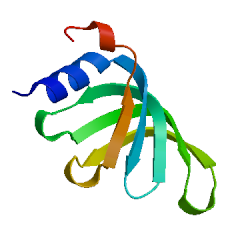
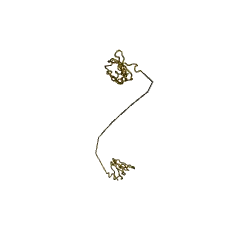
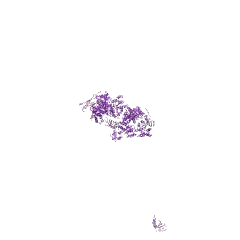
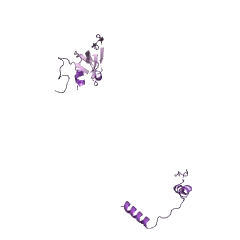
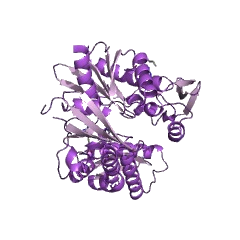
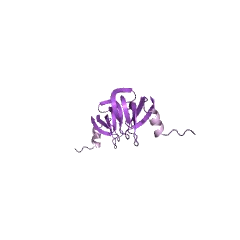
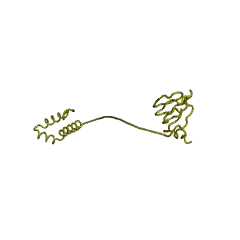

In [ ]:
#given the two ids "P49790" and "Q9UMS4" generate two ego networks of depth for each of them
ego1 = nx.ego_graph(G, "P49790", radius=1, undirected=True, center=True)
ego2 = nx.ego_graph(G, "Q9UMS4", radius=1, undirected=True, center=True)

#find the common nodes between the two ego networks
common_nodes = set(ego1.nodes()).intersection(set(ego2.nodes()))

print("Common nodes between the two ego networks: ", common_nodes)
#show the node attributes
print("Node attributes for the common nodes: ")
for node in common_nodes:
  print(node, G.nodes[node])
  


In [ ]:
# import the customCircleLayout function from the customCircleLayout.py file
from customCircleLayout import customCircleLayout

customCircleLayout2
['Q99567', 'Q9Y6D9', 'P56524', 'Q8TD19', 'Q9BZY3', 'Q8NFH3', 'Q69YH5', 'Q8TEM1', 'P12270', 'O15504', 'O75694', 'P55735', 'Q14493', 'Q13257', 'Q53HL2', 'Q10570', 'P61970', 'Q7Z3B4', 'Q8N1F7', 'Q15796', 'P37198', 'Q9C0J8', 'O95067', 'Q8TDX7', 'P63165', 'Q9H814', 'E5RJF8', 'Q96F70', 'P34932', 'P84022', 'Q9UHI6', 'Q5TCJ3', 'Q9BTX1', 'Q9Y6J5', 'Q14974', 'P52292', 'P17066', 'O60318', 'Q9UPY3', 'P61956', 'Q16630', 'Q9H077', 'H3BLT4', 'Q9NQS7', 'Q9UBU9', 'P35658', 'Q96GD4', 'Q9UKX7', 'O95149', 'P20700', 'P78406', 'Q9BW27', 'Q9UKV8', 'Q9UKF6', 'Q92621', 'Q9UBN7', 'O15397', 'Q9H840', 'Q96HK7', 'O95639', 'O95757', 'O14980', 'Q9P2I0', 'P54652', 'P63279', 'Q12769', 'P41208', 'Q13547', 'P34931', 'Q53GS7', 'P11388', 'P57740', 'Q53FT3', 'H0Y8J7', 'Q8TEQ6', 'Q5SRE5', 'P06493', 'P38646', 'Q8WUM0', '6409', 'Q9NRG9', 'P46060', '2483', 'Q0VDF9', 'P49792', 'Q92797', 'O43301', 'Q9CZA2', 'P57678', 'Q8WXD5', 'P48723', 'Q13485', 'Q8NFH4', 'O43592', 'Q9NWZ8', 'Q92973', 'Q9NPA8', 'O14893', 'P1

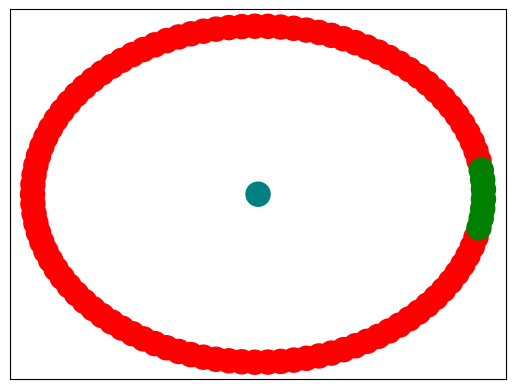

In [ ]:
ego1_nodes = [n for n in ego1.nodes() if n not in common_nodes and n != "P49790"]

pos = customCircleLayout(ego1_nodes, list(common_nodes), 0, (0,0), 3)
pos = {**pos, **{'P49790': (0,0)}}
print(pos)
# draw the ego network of "P49790" with the common nodes in the direction of 135 degrees
G_new = nx.Graph()
G_new.add_nodes_from(ego1_nodes, color='red')
G_new.add_nodes_from(common_nodes, color='green')
G_new.add_nodes_from(["P49790"], color='teal')
print(G_new.nodes())
nx.draw_networkx_nodes(G_new, pos, node_color=[G_new.nodes[n]['color'] for n in G_new.nodes()])




customCircleLayout2
['Q99567', 'Q9Y6D9', 'P56524', 'Q8TD19', 'Q9BZY3', 'Q8NFH3', 'Q69YH5', 'Q8TEM1', 'P12270', 'O15504', 'O75694', 'P55735', 'Q14493', 'Q13257', 'Q53HL2', 'Q10570', 'P61970', 'Q7Z3B4', 'Q8N1F7', 'Q15796', 'P37198', 'Q9C0J8', 'O95067', 'Q8TDX7', 'P63165', 'Q9H814', 'E5RJF8', 'Q96F70', 'P34932', 'P84022', 'Q9UHI6', 'Q5TCJ3', 'Q9BTX1', 'Q9Y6J5', 'Q14974', 'P52292', 'P17066', 'O60318', 'Q9UPY3', 'P61956', 'Q16630', 'Q9H077', 'H3BLT4', 'Q9NQS7', 'Q9UBU9', 'P35658', 'Q96GD4', 'Q9UKX7', 'O95149', 'P20700', 'P78406', 'Q9BW27', 'Q9UKV8', 'Q9UKF6', 'Q92621', 'Q9UBN7', 'O15397', 'Q9H840', 'Q96HK7', 'O95639', 'O95757', 'O14980', 'Q9P2I0', 'P54652', 'P63279', 'Q12769', 'P41208', 'Q13547', 'P34931', 'Q53GS7', 'P11388', 'P57740', 'Q53FT3', 'H0Y8J7', 'Q8TEQ6', 'Q5SRE5', 'P06493', 'P38646', 'Q8WUM0', '6409', 'Q9NRG9', 'P46060', '2483', 'Q0VDF9', 'P49792', 'Q92797', 'O43301', 'Q9CZA2', 'P57678', 'Q8WXD5', 'P48723', 'Q13485', 'Q8NFH4', 'O43592', 'Q9NWZ8', 'Q92973', 'Q9NPA8', 'O14893', 'P1

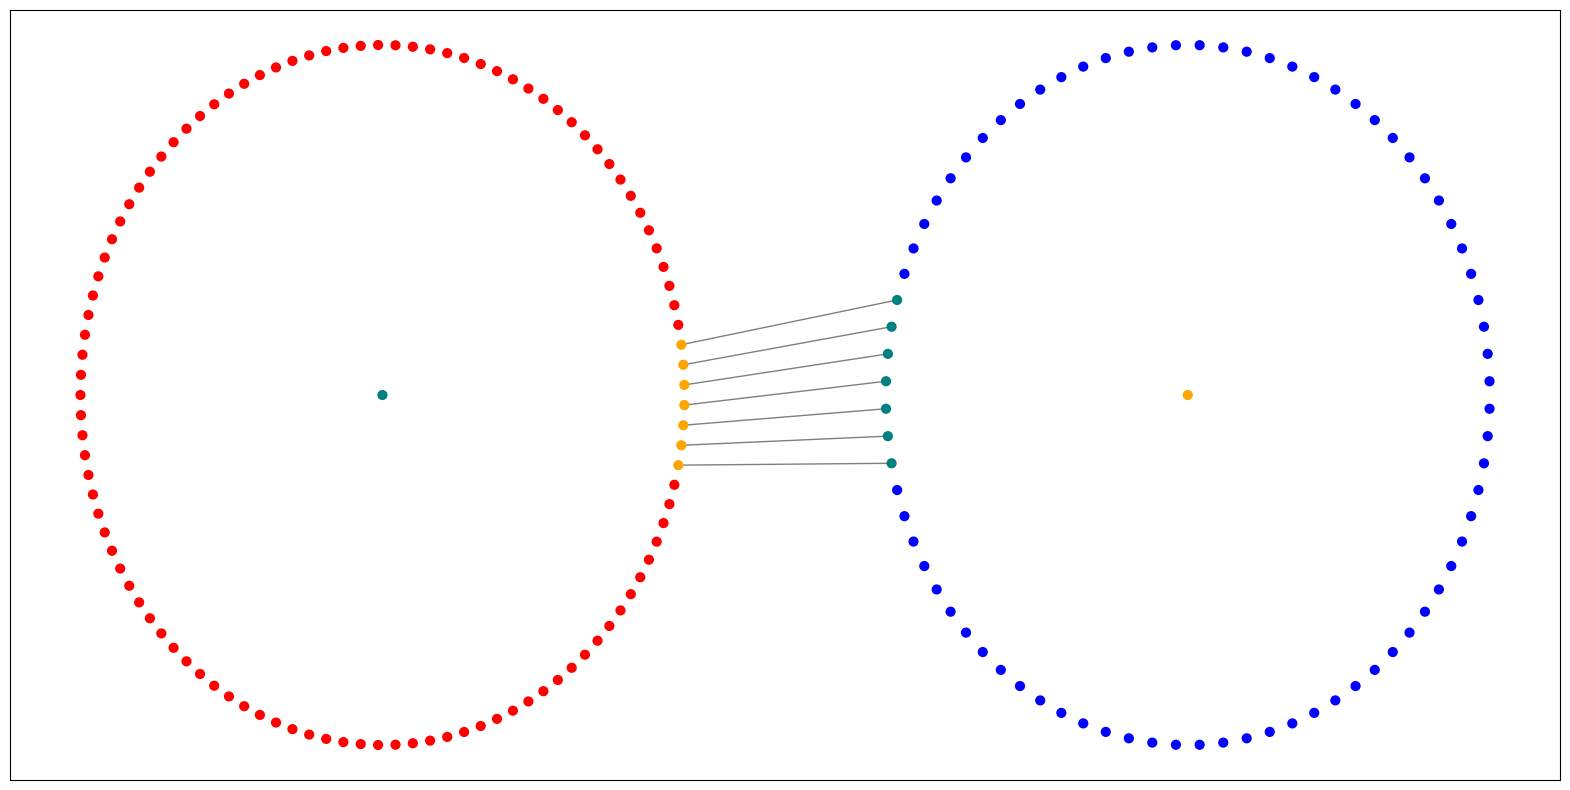

In [ ]:
# layout ego1 and ego2 such that the node "P49790" and "Q9UMS4" is in the center and the other nodes are arranged around it in a circle
# the two circles should be arranged in a way that they do not overlap
# the nodes in the two circles should be colored differently
# the shared nodes should be drawen between the two circles

# create a new graph
G_new = nx.Graph()

ego1_nodes = ego1.nodes()
ego2_nodes = ego2.nodes()
#remove the common nodes and the center nodes from the two ego networks

ego1_nodes = [n for n in ego1_nodes if n != "P49790"]
ego2_nodes = [n for n in ego2_nodes if n != "Q9UMS4"]

ego1_notCommon = [n for n in ego1_nodes if n not in common_nodes and n != "P49790"]
ego2_notCommon = [n for n in ego2_nodes if n not in common_nodes and n != "Q9UMS4"]

# duplicate the common nodes in the two ego networks add ego1 and ego2 to the node names
ego1_common_nodes = [n+"_ego1" for n in common_nodes]
ego2_common_nodes = [n+"_ego2" for n in common_nodes]



# add the nodes from the two ego networks
G_new.add_nodes_from(ego1_notCommon, color='red')
G_new.add_nodes_from(ego2_notCommon, color='blue')

G_new.add_nodes_from(["P49790"], color='teal')
G_new.add_nodes_from(["Q9UMS4"], color='orange')

G_new.add_nodes_from(ego1_common_nodes, color='orange')
G_new.add_nodes_from(ego2_common_nodes, color='teal')

#add edges between the duplicated common nodes
for i, n in enumerate(common_nodes):
    G_new.add_edge(n+"_ego1", n+"_ego2")


# set the positions of the nodes
pos1 = customCircleLayout(ego1_notCommon, ego1_common_nodes , 0 ,(2, 2), 1.5, reverse=True)
pos2 = customCircleLayout(ego2_notCommon, ego2_common_nodes, 180 ,(6, 2), 1.5)

# set the positions of the center nodes
pos_center = {"P49790": (2, 2), "Q9UMS4": (6, 2)}

pos = {**pos1, **pos2, **pos_center}
print(pos)
# square figure
plt.figure(figsize=(20,10))

# draw the nodes
nx.draw_networkx_nodes(G_new, pos, node_size=40, node_color=[G_new.nodes[n]['color'] for n in G_new.nodes()])
# draw the edges
nx.draw_networkx_edges(G_new, pos, width=1.0, alpha=0.5)


In [5]:
# drop the attribute stringdb::STRING_style, stringdb::sequence, stingdb::enhancedLabel_Passthrough
# as they are not needed for the analysis
for node in G.nodes():
    G.nodes[node].pop('stringdb::STRING style', None)
    G.nodes[node].pop('stringdb::sequence', None)
    G.nodes[node].pop('stringdb::enhancedLabel Passthrough', None)

# write the graph to a new graphml file
nx.write_graphml(G, "../data/graphml_string_cleaned.graphml")


NameError: name 'G' is not defined